# Задача 1. 


Properties of Matrix 1:
Non-negative elements: True
Row sums equal to 1: True
Maximum eigenvalue is 1: True
Maximum absolute eigenvalue: 0.9999999999999989



Properties of Matrix 2:
Non-negative elements: True
Row sums equal to 1: True
Maximum eigenvalue is 1: True
Maximum absolute eigenvalue: 1.0000000000000004



Properties of Matrix 3:
Non-negative elements: True
Row sums equal to 1: True
Maximum eigenvalue is 1: True
Maximum absolute eigenvalue: 1.0000000000000004




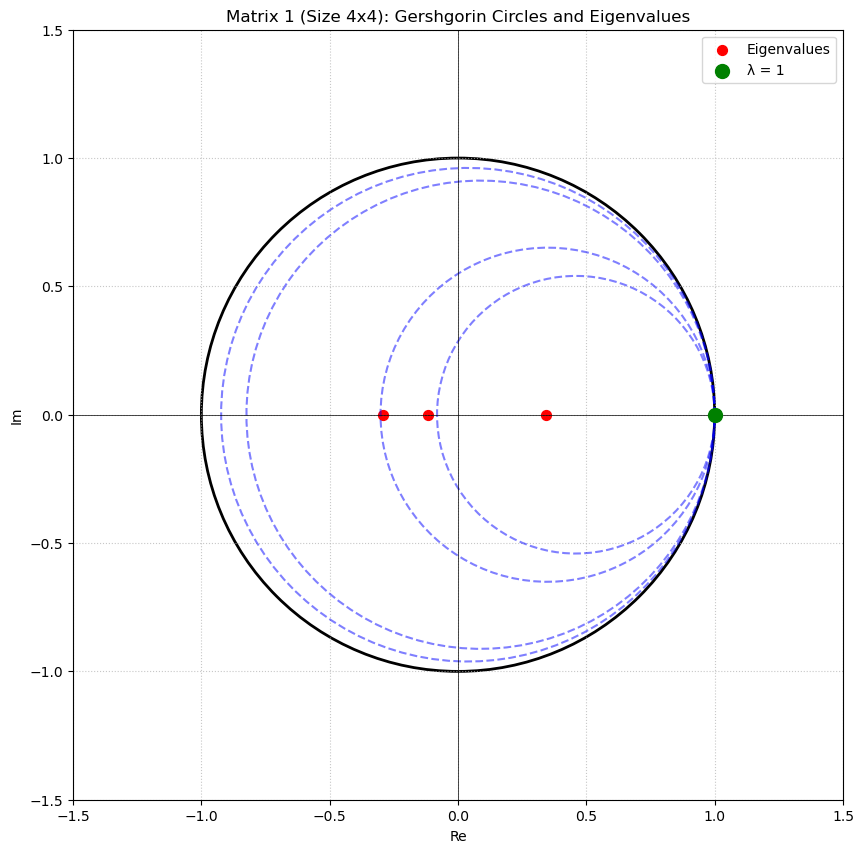

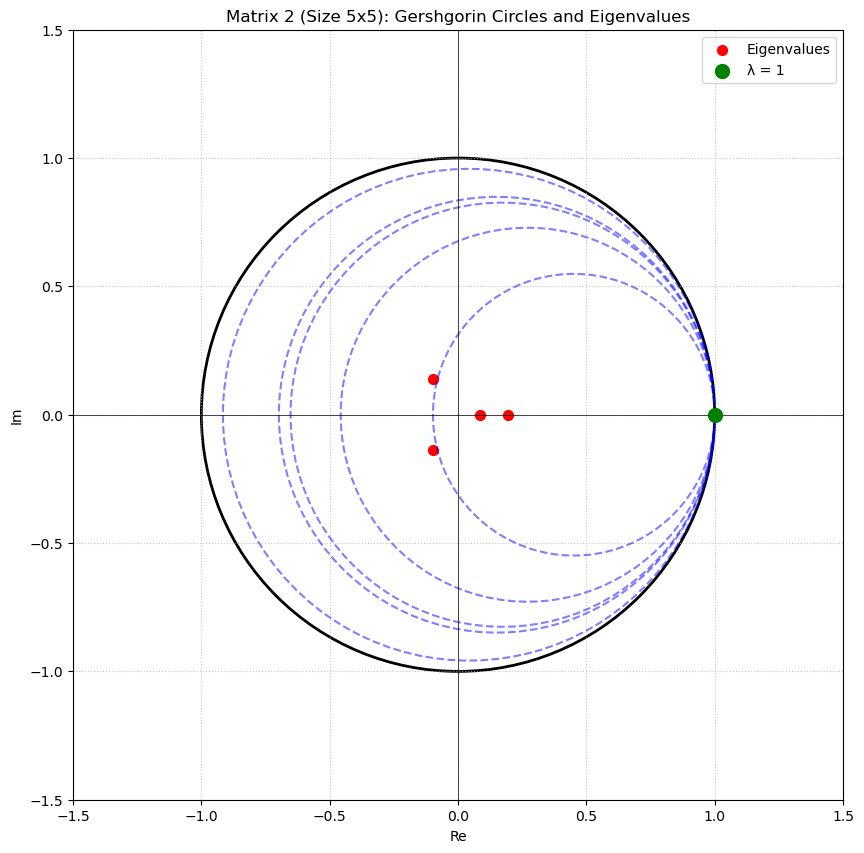

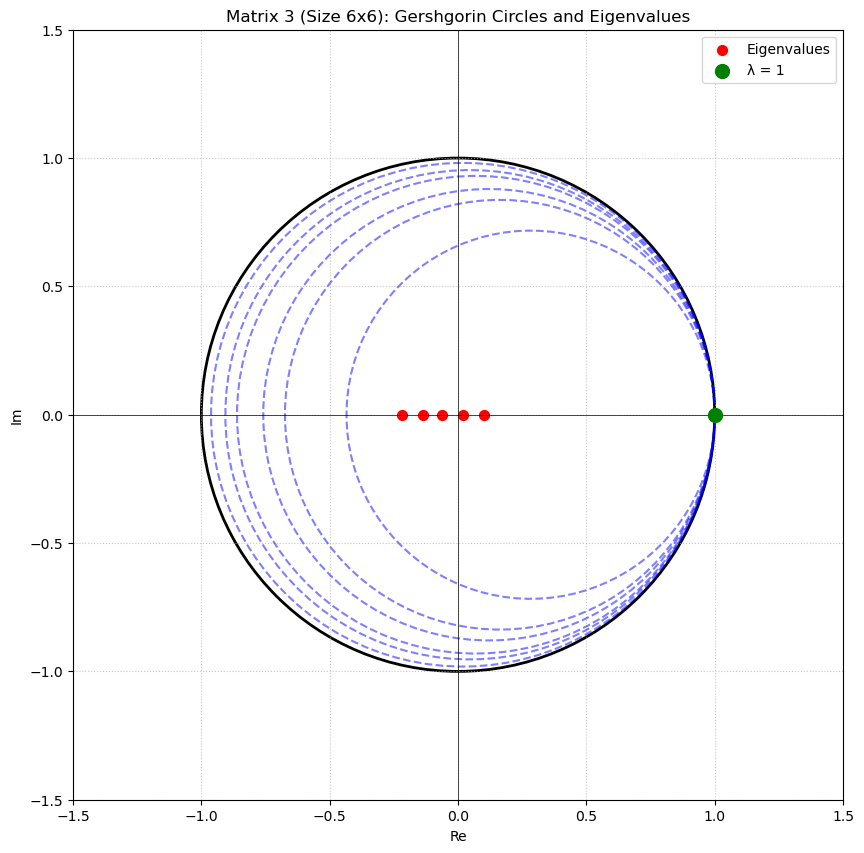

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_stochastic_matrix(n):
    A = np.random.rand(n, n)
    return A / A.sum(axis=1)[:, np.newaxis]

def plot_gershgorin_and_eigenvalues(A, title=""):
    n = A.shape[0]
    centers = np.diag(A)
    radii = np.sum(np.abs(A), axis=1) - np.abs(centers)
    eigenvalues = np.linalg.eigvals(A)
    
    plt.figure(figsize=(10, 10))
    theta = np.linspace(0, 2*np.pi, 100)
    for i in range(n):
        x = centers[i] + radii[i] * np.cos(theta)
        y = radii[i] * np.sin(theta)
        plt.plot(x, y, 'b--', alpha=0.5)
    
    plt.scatter(eigenvalues.real, eigenvalues.imag, color='r', s=50, label='Eigenvalues')
    plt.scatter([1], [0], color='g', s=100, label='λ = 1', zorder=5)
    
    unit_circle = plt.Circle((0, 0), 1, color='k', fill=False, linestyle='-', linewidth=2)
    plt.gca().add_artist(unit_circle)
    
    plt.axhline(0, color='k', linewidth=0.5)
    plt.axvline(0, color='k', linewidth=0.5)
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.xlabel("Re")
    plt.ylabel("Im")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

def verify_stochastic_properties(A):
    is_nonnegative = np.all(A >= 0)
    row_sums = np.sum(A, axis=1)
    is_row_sum_one = np.allclose(row_sums, 1)
    max_eigenvalue = max(abs(np.linalg.eigvals(A)))
    is_max_eigenvalue_one = np.isclose(max_eigenvalue, 1)
    
    print(f"Non-negative elements: {is_nonnegative}")
    print(f"Row sums equal to 1: {is_row_sum_one}")
    print(f"Maximum eigenvalue is 1: {is_max_eigenvalue_one}")
    print(f"Maximum absolute eigenvalue: {max_eigenvalue}")

def main():
    num_matrices = 3
    matrix_sizes = [4, 5, 6]
    
    for i, size in enumerate(matrix_sizes):
        A = generate_stochastic_matrix(size)
        title = f"Matrix {i+1} (Size {size}x{size}): Gershgorin Circles and Eigenvalues"
        plot_gershgorin_and_eigenvalues(A, title=title)
        print(f"\nProperties of Matrix {i+1}:")
        verify_stochastic_properties(A)
        print("\n" + "="*50 + "\n")

if __name__ == "__main__":
    main()


# Задача 2.


PageRank для маленького графа:
[0.13808259 0.12714821 0.09979266 0.16807593 0.10743894 0.08915544
 0.09144595 0.06545831 0.05658036 0.05682161]
Количество итераций: 13
Наибольший PageRank у узла 4


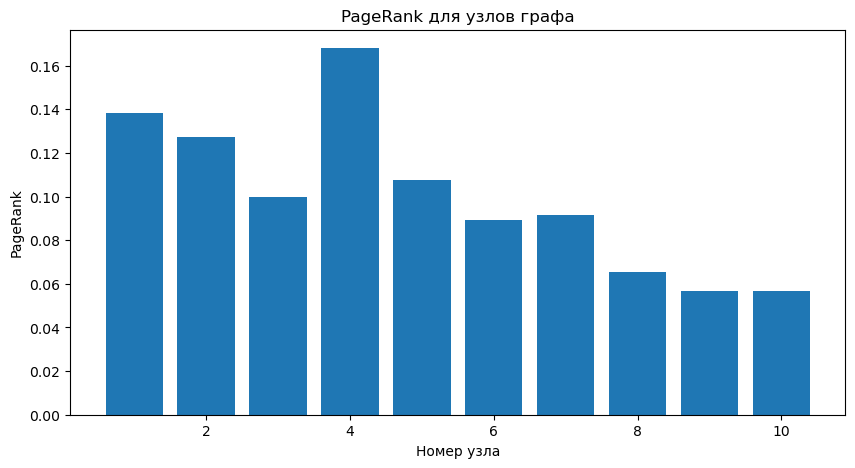

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def create_graph():
    return np.array([
        [0, 1, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 0, 1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    ], dtype=float)

def create_google_matrix(l, beta=0.8):
    n = l.shape[0]
    L = np.sum(l, axis=0)
    G = np.where(L != 0, l / L, 1/n)
    return beta * G + (1 - beta) / n

def pagerank(G, tol=1e-4, max_iter=1000):
    n = G.shape[0]
    p = np.ones(n) / n
    iterations = 0
    
    for _ in range(max_iter):
        p_new = G @ p
        if np.linalg.norm(p_new - p, ord=1) < tol:
            return p_new, iterations
        p = p_new
        iterations += 1
    
    return p, iterations

def plot_pagerank(p):
    plt.figure(figsize=(10, 5))
    plt.bar(range(1, len(p) + 1), p)
    plt.title("PageRank для узлов графа")
    plt.xlabel("Номер узла")
    plt.ylabel("PageRank")
    plt.show()

# Основной код
l = create_graph()
G = create_google_matrix(l)
p, iterations = pagerank(G)

print("PageRank для маленького графа:")
print(p)
print(f"Количество итераций: {iterations}")
print(f"Наибольший PageRank у узла {np.argmax(p) + 1}")

plot_pagerank(p)


In [3]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix

# Загрузка графа из файла, игнорируя строки с комментариями
file_path = 'web-Stanford.txt'
edges = pd.read_csv(file_path, comment='#', sep='\t', header=None, names=['from', 'to'])

# Создание разреженной матрицы смежности
num_nodes = max(edges['from'].max(), edges['to'].max())
data = np.ones(len(edges))
row = edges['to'].values - 1  
col = edges['from'].values - 1
adj_matrix = csr_matrix((data, (row, col)), shape=(num_nodes, num_nodes))

# Создание стохастической матрицы G с учетом dangling nodes
out_degree = np.array(adj_matrix.sum(axis=0)).flatten()
dangling_nodes = out_degree == 0
out_degree[dangling_nodes] = 1  # Избегаем деления на ноль

G = adj_matrix.multiply(1 / out_degree)  
G = G.transpose()

# Параметры для вычисления PageRank
beta = 0.8
e = np.ones((num_nodes, 1)) / num_nodes  # Вектор для учета переходов на все узлы

# Вычисление PageRank с использованием метода степенной итерации
n = G.shape[0]
p = np.ones((n, 1)) / n  # Начальное распределение вероятностей

for iteration in range(100):
    p_new = beta * G @ p + (1 - beta) * e  # Обновление вектора PageRank
    if np.linalg.norm(p_new - p, ord=1) < 1e-4:  # Проверка на сходимость
        break
    p = p_new

# Вывод результатов
print(f"PageRank рассчитан за {iteration + 1} итераций.")
print(f"Наибольший PageRank у узла {np.argmax(p) + 1}.")


PageRank рассчитан за 7 итераций.
Наибольший PageRank у узла 179283.


1.	Матрица  G  стохастическая:
	•	Сумма элементов в каждом столбце равна 1.
	2.	Свойство стохастических матриц:
Для любой стохастической матрицы максимальное собственное значение равно 1 (следует из теоремы Перрона-Фробениуса).
	3.	 G  дополнительно корректируется с учетом параметра  \beta , но это не изменяет максимальное собственное значение, так как итоговая матрица остается стохастической.

# Задача 3.

In [4]:
import numpy as np
from scipy.linalg import hilbert, pascal, solve
from scipy.sparse import diags

def rayleigh_iteration(A, sigma, tol=1e-10, max_iter=1000):
    n = A.shape[0]
    x = np.random.rand(n)
    x /= np.linalg.norm(x)  # Нормализация вектора

    for _ in range(max_iter):
        try:
            y = solve(A - sigma * np.eye(n), x)  # Решение системы
        except np.linalg.LinAlgError:
            break
        
        x_new = y / np.linalg.norm(y)  # Нормализация нового вектора

        if np.linalg.norm(x_new - x) < tol:  # Проверка на сходимость
            break
        x = x_new

    lambda_min = (x.T @ A @ x) / (x.T @ x)  # Вычисление собственного значения
    return lambda_min, x

def find_nearest_eigenvalue(A, sigma):
    return rayleigh_iteration(A, sigma)

def lemer_matrix(n):
    # Создание матрицы Лемера
    return np.array([[min(i + 1, j + 1) / max(i + 1, j + 1) for j in range(n)] for i in range(n)])

def tridiagonal_matrix(n):
    # Создание симметричной трёхдиагональной матрицы
    diagonals = [2 * np.ones(n), -1 * np.ones(n - 1), -1 * np.ones(n - 1)]
    return diags(diagonals, [0, -1, 1]).toarray()

def solve_for_all_matrices():
    for n in range(2, 11):
        print(f"n = {n}")
        
        # Матрица Гильберта
        H = hilbert(n)
        lambda_min, _ = rayleigh_iteration(H, 0)
        print(f"  Матрица Гильберта: min(lambda) ≈ {lambda_min:.6e}")
        
        # Матрица Лемера
        L = lemer_matrix(n)
        lambda_min, _ = rayleigh_iteration(L, 0)
        print(f"  Матрица Лемера: min(lambda) ≈ {lambda_min:.6e}")
        
        # Матрица Паскаля
        P = pascal(n, kind='symmetric')
        lambda_min, _ = rayleigh_iteration(P, 0)
        print(f"  Матрица Паскаля: min(lambda) ≈ {lambda_min:.6e}")
        
        # Трехдиагональная матрица
        T = tridiagonal_matrix(n)
        lambda_min, _ = rayleigh_iteration(T, 0)
        print(f"  Трехдиагональная матрица: min(lambda) ≈ {lambda_min:.6e}")
        
        print("-" * 40)

# Выполнение расчетов для всех матриц
solve_for_all_matrices()


n = 2
  Матрица Гильберта: min(lambda) ≈ 6.574145e-02
  Матрица Лемера: min(lambda) ≈ 5.000000e-01
  Матрица Паскаля: min(lambda) ≈ 3.819660e-01
  Трехдиагональная матрица: min(lambda) ≈ 1.000000e+00
----------------------------------------
n = 3
  Матрица Гильберта: min(lambda) ≈ 2.687340e-03
  Матрица Лемера: min(lambda) ≈ 3.020196e-01
  Матрица Паскаля: min(lambda) ≈ 1.270167e-01
  Трехдиагональная матрица: min(lambda) ≈ 5.857864e-01
----------------------------------------
n = 4
  Матрица Гильберта: min(lambda) ≈ 9.670230e-05
  Матрица Лемера: min(lambda) ≈ 2.077755e-01
  Матрица Паскаля: min(lambda) ≈ 3.801602e-02
  Трехдиагональная матрица: min(lambda) ≈ 3.819660e-01
----------------------------------------
n = 5
  Матрица Гильберта: min(lambda) ≈ 3.287929e-06
  Матрица Лемера: min(lambda) ≈ 1.560195e-01
  Матрица Паскаля: min(lambda) ≈ 1.083536e-02
  Трехдиагональная матрица: min(lambda) ≈ 2.679492e-01
----------------------------------------
n = 6
  Матрица Гильберта: min(lambd

In [5]:
# Пример использования функции для нахождения ближайшего собственного значения
A = hilbert(5)  
sigma = 0.1     
lambda_near, eigenvector = find_nearest_eigenvalue(A, sigma)
print(f"Ближайшее к {sigma} собственное значение: {lambda_near:.6e}")

Ближайшее к 0.1 собственное значение: 1.140749e-02


# Задача 4.

Мы можем вычислить PageRank с помощью библиотек на Python. Будем использовать бибилотеку networkx для работы с графами, она может быть установлена с помощью следующей команды

conda install networkx

Возьмём простой пример графа Zachary karate club. Этот граф был собран вручную в 1977, и является классическим графом для анализа соцсетей.
https://en.wikipedia.org/wiki/Zachary%27s_karate_club  

  

In [6]:
!pip install networkx

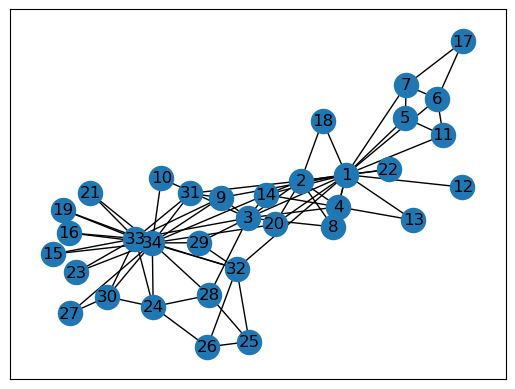

In [7]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx
kn = nx.read_gml('graph.gml')
#nx.write_gml(kn, 'karate2.gml')
nx.draw_networkx(kn) #Draw the graph

Сейчас мы можем вычислить PageRank, используя функцию, встроенную в NetworkX. Мы также изобразим вершины графа пропорционально тому, наскольку они важны в смысле величины PageRank'a.

  

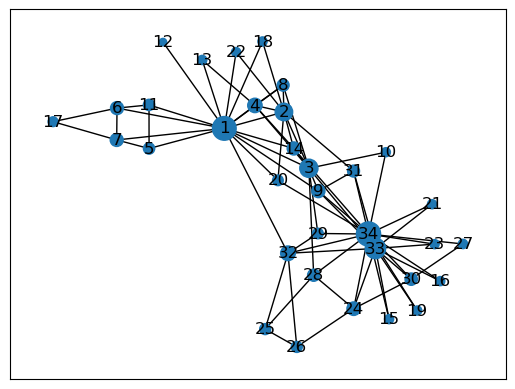

In [8]:
pr = nx.algorithms.link_analysis.pagerank(kn)
pr_vector = list(pr.values())
pr_vector = np.array(pr_vector) * 3000
nx.draw_networkx(kn, node_size=pr_vector, labels=None)

Самостоятельно проделайте это всё для страниц stanford.edu

Граф загружен: 23 узлов и 21 рёбер при max_edges=25.
Узел с наибольшим PageRank: 57031, значение PageRank: 0.081528


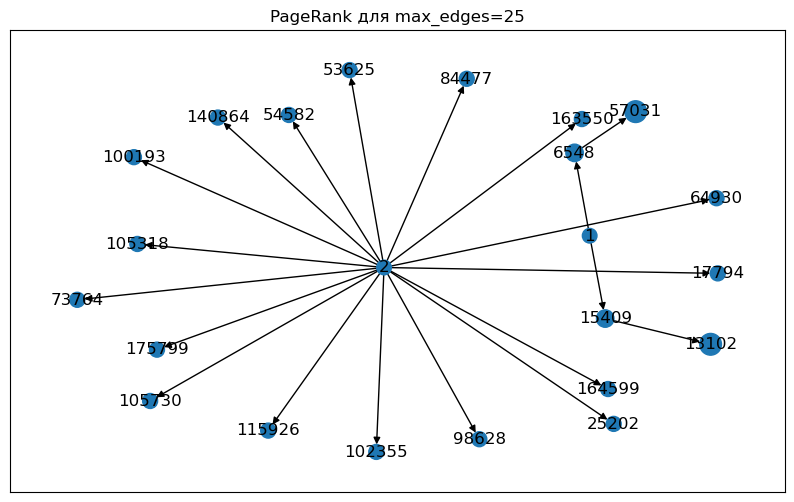

Граф загружен: 219 узлов и 246 рёбер при max_edges=250.
Узел с наибольшим PageRank: 2, значение PageRank: 0.214740


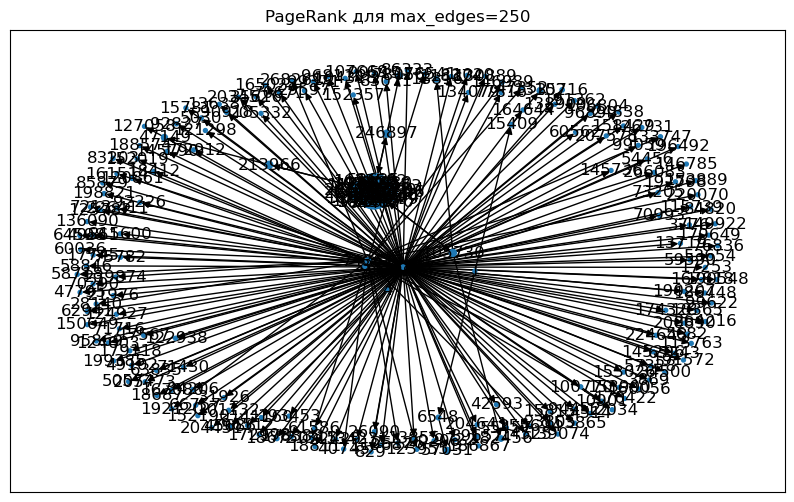

Граф загружен: 1369 узлов и 2496 рёбер при max_edges=2500.
Узел с наибольшим PageRank: 2, значение PageRank: 0.045724


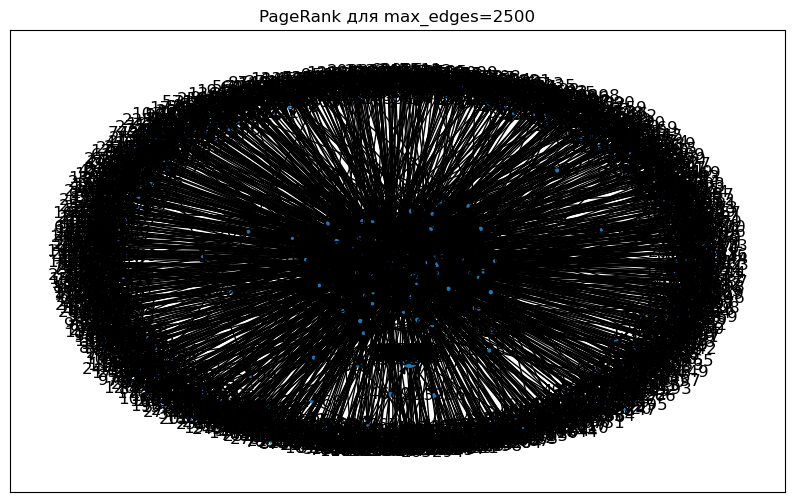

Граф загружен: 281903 узлов и 2312497 рёбер при max_edges=2500000.
Узел с наибольшим PageRank: 89073, значение PageRank: 0.010006


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

file_path = 'web-Stanford.txt'

def load_graph(file_path, max_edges):
    G = nx.DiGraph()
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            if i >= max_edges:
                break
            if not line.startswith('#'):
                from_node, to_node = map(int, line.split())
                G.add_edge(from_node, to_node)
    return G

edge_limits = [25, 250, 2500, 2500000]

for max_edges in edge_limits:
    G = load_graph(file_path, max_edges)
    
    print(f"Граф загружен: {G.number_of_nodes()} узлов и {G.number_of_edges()} рёбер при max_edges={max_edges}.")

    pr = nx.pagerank(G)
    
    max_pr_node = max(pr, key=pr.get)
    print(f"Узел с наибольшим PageRank: {max_pr_node}, значение PageRank: {pr[max_pr_node]:.6f}")

    if max_edges < 100000:
        pr_vector = np.array(list(pr.values())) * 3000
        plt.figure(figsize=(10, 6))
        nx.draw_networkx(G, node_size=pr_vector, labels=None)
        plt.title(f"PageRank для max_edges={max_edges}")
        plt.show()


# Задача 5. 

## Доказательство

Докажем, что для матрицы $D + \rho u u^*$ характеристический многочлен имеет вид:

$$
\operatorname{det}\left(I + \rho (D - \lambda I)^{-1} u u^*\right) = 1 + \rho \sum_{i=1}^n \frac{|u_i|^2}{d_i - \lambda}.
$$

---

### Шаг 1: Свойство определителя матрицы $I + w u^*$

Из линейной алгебры известно, что для матрицы вида $I + w u^*$, где $w \in \mathbb{C}^n$, $u^*$ — транспонированный (или сопряженный) вектор:

$$
\operatorname{det}(I + w u^*) = 1 + \operatorname{trace}(w u^*).
$$

---

### Шаг 2: Применение к $I + \rho (D - \lambda I)^{-1} u u^*$

Заменим $w = \rho (D - \lambda I)^{-1} u$ и $u^*$. Тогда:

$$
\operatorname{det}\left(I + \rho (D - \lambda I)^{-1} u u^*\right) = 1 + \operatorname{trace}\left(\rho (D - \lambda I)^{-1} u u^*\right).
$$

---

### Шаг 3: Упрощение следа

Используем свойство следа матрицы:

$$
\operatorname{trace}(A B) = \operatorname{trace}(B A).
$$

Применяя это к $\operatorname{trace}\left((D - \lambda I)^{-1} u u^*\right)$, получаем:

$$
\operatorname{trace}\left((D - \lambda I)^{-1} u u^*\right) = \operatorname{trace}\left(u^* (D - \lambda I)^{-1} u \right).
$$

Поскольку $u u^*$ — матрица ранга 1, результат следа можно записать как сумму по компонентам вектора $u$:

$$
\operatorname{trace}\left((D - \lambda I)^{-1} u u^*\right) = \sum_{i=1}^n \frac{|u_i|^2}{d_i - \lambda}.
$$

---

### Шаг 4: Подставляем результат

Подставим полученное выражение для следа в формулу определителя:

$$
\operatorname{det}\left(I + \rho (D - \lambda I)^{-1} u u^*\right) = 1 + \rho \sum_{i=1}^n \frac{|u_i|^2}{d_i - \lambda}.
$$

---

